# EMU vs SAVONT Analysis on Zymo ONT Data

This notebook compares taxonomic profiles from EMU and SAVONT on Zymo mock community data.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
#sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15/2.54, 7/2.54)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'arial'
sns.set_palette('muted')

## Load Data

In [116]:
# Load the taxonomic profiles
emu_df = pd.read_csv('ont-zymo-analysis/emu_rep1_species.tsv', sep='\t')
savont_df = pd.read_csv('ont-zymo-analysis/savont_rep1_species.tsv', sep='\t')

# Filter out unmapped and unclassified
emu_df = emu_df[~emu_df['tax_id'].isin(['unmapped', 'mapped_unclassified'])].copy()
savont_df = savont_df[~savont_df['tax_id'].isin(['unmapped', 'mapped_unclassified'])].copy()

# Remove rows with 0 abundance
emu_df = emu_df[emu_df['abundance'] > 0].copy()
savont_df = savont_df[savont_df['abundance'] > 0].copy()

print(f"EMU detected {len(emu_df)} species")
print(f"SAVONT detected {len(savont_df)} species")

EMU detected 19 species
SAVONT detected 11 species


In [117]:
# Define true positives (species truly present in Zymo mock)
true_positives = {
    'Faecalibacterium prausnitzii',
    'Veillonella rogosae',
    'Roseburia hominis',
    'Bacteroides fragilis',
    'Prevotella corporis',
    'Bifidobacterium adolescentis',
    'Fusobacterium nucleatum',
    'Limosilactobacillus fermentum',
    'Clostridioides difficile',
    'Escherichia coli',
    'Candida albicans',
    'Salmonella enterica',
    'Enterococcus faecalis',
    'Clostridium perfringens',
    'Akkermansia muciniphila',
    'Veillonella parvula'
}

## Plot 1: Log-Log Scatter Plot (EMU vs SAVONT)

In [118]:
# Merge the datasets on species name
merged_df = pd.merge(
    emu_df[['species', 'abundance']],
    savont_df[['species', 'abundance']],
    on='species',
    how='outer',
    suffixes=('_emu', '_savont')
)

# Set threshold for projection (1/10th of minimum detected abundance)
min_emu = emu_df['abundance'].min()
min_savont = savont_df['abundance'].min()
threshold_emu = 1e-4  #min_emu / 10
threshold_savont = 1e-4  #min_savont / 10

# Fill NaN values with threshold for plotting
merged_df['abundance_emu_plot'] = merged_df['abundance_emu'].fillna(threshold_emu)
merged_df['abundance_savont_plot'] = merged_df['abundance_savont'].fillna(threshold_savont)

# Identify which points are projected
merged_df['emu_only'] = merged_df['abundance_savont'].isna()
merged_df['savont_only'] = merged_df['abundance_emu'].isna()
merged_df['both'] = ~(merged_df['emu_only'] | merged_df['savont_only'])
merged_df['true_positive'] = merged_df['species'].isin(true_positives)

print(f"Species in both: {merged_df['both'].sum()}")
print(f"Species only in emu: {merged_df['emu_only'].sum()}")
print(f"Species only in savont: {merged_df['savont_only'].sum()}")

Species in both: 11
Species only in emu: 8
Species only in savont: 0


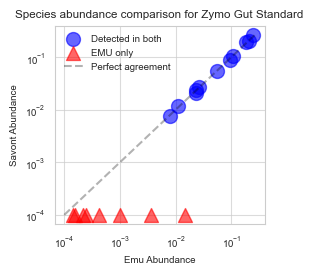

In [119]:
# Create log-log scatter plot
fig, ax = plt.subplots(figsize=(7/2.54, 7/2.54))

# Plot points detected in both
both_data = merged_df[merged_df['both']]
ax.scatter(both_data['abundance_emu_plot'], both_data['abundance_savont_plot'],
           alpha=0.6, s=100, label='Detected in both', color='blue')

# Plot points only in EMU (projected to left axis)
emu_only_data = merged_df[merged_df['emu_only']]
ax.scatter(emu_only_data['abundance_emu_plot'], emu_only_data['abundance_savont_plot'],
           alpha=0.6, s=100, label='EMU only', color='red', marker='^')

# Plot points only in SAVONT (projected to bottom axis)
#savont_only_data = merged_df[merged_df['savont_only']]
#ax.scatter(savont_only_data['abundance_emu_plot'], savont_only_data['abundance_savont_plot'],
#           alpha=0.6, s=100, label='SAVONT only', color='green', marker='v')

# Add diagonal line (perfect agreement)
min_val = min(threshold_emu, threshold_savont)
max_val = max(merged_df['abundance_emu_plot'].max(), merged_df['abundance_savont_plot'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Perfect agreement')

# Set log scale
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Emu Abundance')
ax.set_ylabel('Savont Abundance')
ax.set_title('Species abundance comparison for Zymo Gut Standard')
ax.legend(frameon=False)
ax.grid(True, alpha=0.7)

plt.tight_layout()
plt.savefig('figures/emu_vs_savont_zymo_species_abundance.png', dpi=300, bbox_inches='tight')

## Plot 2: Side-by-Side Barplot with True/False Positives

In [120]:
# Get all unique species detected by either tool
all_species = set(emu_df['species'].tolist()) | set(savont_df['species'].tolist())

# Create a dataframe for plotting
plot_data = []
for species in all_species:
    is_true_positive = species in true_positives
    
    # Get EMU abundance
    emu_abund = emu_df[emu_df['species'] == species]['abundance'].values
    emu_abund = emu_abund[0] if len(emu_abund) > 0 else (0 if is_true_positive else np.nan)
    
    # Get SAVONT abundance
    savont_abund = savont_df[savont_df['species'] == species]['abundance'].values
    savont_abund = savont_abund[0] if len(savont_abund) > 0 else (0 if is_true_positive else np.nan)
    
    # Skip if both are NaN (false positive not detected by either)
    if not (pd.isna(emu_abund) and pd.isna(savont_abund)):
        plot_data.append({
            'species': species,
            'emu': emu_abund if not pd.isna(emu_abund) else 0,
            'savont': savont_abund if not pd.isna(savont_abund) else 0,
            'is_true_positive': is_true_positive
        })

plot_df = pd.DataFrame(plot_data)

# Sort by total abundance (emu + savont) descending
plot_df['total'] = plot_df['emu'] + plot_df['savont']
plot_df = plot_df.sort_values('total', ascending=False).reset_index(drop=True)

print(f"\nTotal species to plot: {len(plot_df)}")
print(f"True positives: {plot_df['is_true_positive'].sum()}")
print(f"False positives: {(~plot_df['is_true_positive']).sum()}")


Total species to plot: 19
True positives: 13
False positives: 6


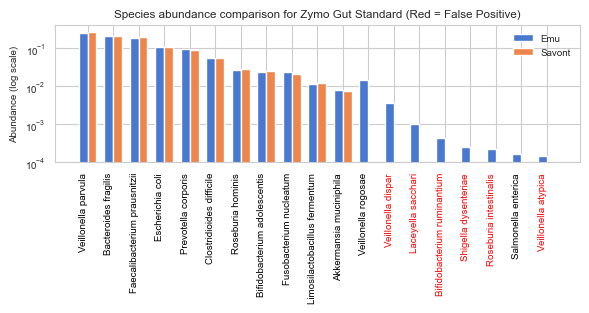

In [121]:
# Create side-by-side barplot
fig, ax = plt.subplots(figsize=(15/2.54, 8/2.54))

x = np.arange(len(plot_df))
width = 0.35

# Replace 0 with small value for log scale visualization
log_threshold = 0
emu_plot = plot_df['emu'].replace(0, log_threshold)
savont_plot = plot_df['savont'].replace(0, log_threshold)

# Create bars
bars1 = ax.bar(x - width/2, emu_plot, width, label='Emu', alpha=1.0)
bars2 = ax.bar(x + width/2, savont_plot, width, label='Savont', alpha=1.0)

# Set log scale
ax.set_yscale('log')

# Set x-axis labels with color coding
ax.set_xticks(x)
ax.set_xticklabels(plot_df['species'], rotation=90, ha='right')

# Color x-tick labels: red for false positives, black for true positives
for i, (tick, is_tp) in enumerate(zip(ax.get_xticklabels(), plot_df['is_true_positive'])):
    tick.set_color('black' if is_tp else 'red')

# Labels and title
ax.set_ylabel('Abundance (log scale)')
ax.set_xlabel('')
ax.set_title('Species abundance comparison for Zymo Gut Standard (Red = False Positive)')
ax.legend(frameon=False)
#ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/emu_vs_savont_zymo_species_abundance.png', dpi=300, bbox_inches='tight')

## Summary Statistics

In [122]:
# Calculate summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print("\nEMU:")
emu_tp = plot_df[plot_df['is_true_positive'] & (plot_df['emu'] > 0)]
emu_fp = plot_df[~plot_df['is_true_positive'] & (plot_df['emu'] > 0)]
print(f"  True positives detected: {len(emu_tp)} / {len(true_positives)}")
print(f"  False positives: {len(emu_fp)}")

print("\nSAVONT:")
savont_tp = plot_df[plot_df['is_true_positive'] & (plot_df['savont'] > 0)]
savont_fp = plot_df[~plot_df['is_true_positive'] & (plot_df['savont'] > 0)]
print(f"  True positives detected: {len(savont_tp)} / {len(true_positives)}")
print(f"  False positives: {len(savont_fp)}")

print("\nMissing true positives:")
detected_species = set(plot_df[plot_df['is_true_positive']]['species'])
missing = true_positives - detected_species
if missing:
    for sp in missing:
        print(f"  - {sp}")
else:
    print("  None")

print("\n" + "=" * 60)

SUMMARY STATISTICS

EMU:
  True positives detected: 13 / 16
  False positives: 6

SAVONT:
  True positives detected: 11 / 16
  False positives: 0

Missing true positives:
  - Enterococcus faecalis
  - Candida albicans
  - Clostridium perfringens



## Plot 3: Performance Comparison (RAM and Runtime)


Performance Summary:
----------------------------------------
Emu     :   8.2 GB,    660 sec
Savont  :   1.6 GB,     20 sec
----------------------------------------
Speedup: 33.0x faster
Memory: 5.1x more RAM


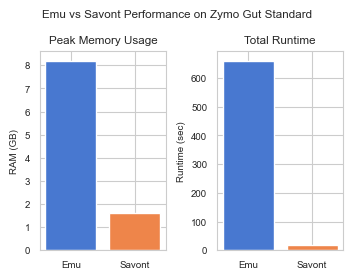

In [125]:
# Performance metrics
performance_data = {
    'Tool': ['Emu', 'Savont'],
    'RAM (GB)': [8.2, 1.6],
    'Runtime (sec)': [660, 20]
}

perf_df = pd.DataFrame(performance_data)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9/2.54, 7/2.54))

# Get color palette
colors = sns.color_palette('muted')

# Plot 1: RAM Usage
ax1.bar(perf_df['Tool'], perf_df['RAM (GB)'], alpha=1.0, color=[colors[0], colors[1]])
ax1.set_ylabel('RAM (GB)')
ax1.set_xlabel('')
ax1.set_title('Peak Memory Usage')
#ax1.grid(True, alpha=0.7, axis='y')

# Plot 2: Runtime
ax2.bar(perf_df['Tool'], perf_df['Runtime (sec)'], alpha=1.0, color=[colors[0], colors[1]])
ax2.set_ylabel('Runtime (sec)')
ax2.set_xlabel('')
ax2.set_title('Total Runtime')
#ax2.grid(True, alpha=0.7, axis='y')
plt.suptitle('Emu vs Savont Performance on Zymo Gut Standard')
plt.tight_layout()
#plt.show()

# Print summary
print("\nPerformance Summary:")
print("-" * 40)
for _, row in perf_df.iterrows():
    print(f"{row['Tool']:8s}: {row['RAM (GB)']:5.1f} GB, {row['Runtime (sec)']:6.0f} sec")
print("-" * 40)
print(f"Speedup: {perf_df.loc[0, 'Runtime (sec)'] / perf_df.loc[1, 'Runtime (sec)']:.1f}x faster")
print(f"Memory: {perf_df.loc[0, 'RAM (GB)'] / perf_df.loc[1, 'RAM (GB)']:.1f}x more RAM")

plt.savefig('figures/emu_savont_performance_comparison.png', dpi=300, bbox_inches='tight')